# Deconvolution 1.1 - Analysis

## Introduction

Here the analysis of the deconvolution results from lung samples is performed.

In [2]:
setwd(here::here())

## Libraries

In [3]:
library(here)
library(glue)
library(tidyverse)
library(patchwork)
library(Seurat)
library(SingleCellExperiment)
library(SpatialExperiment)
library(HDF5Array)
library(SPOTlight)
library(sccomp)
library(scater)
library(scran)
library(ggspavis)
library(spacexr)
library(pheatmap)
library(svglite)

here() starts at /home/groups/singlecell/cvicente/SP-COVID/visium/1-deconvolution

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dp

## Load data

In [4]:
spe <- loadHDF5SummarizedExperiment(
  dir = "~/SP-COVID/visium/0-processing/out/3-annot_lung_spe" %>%
    glue::glue() %>%
    here::here()
)
rownames(spatialCoords(spe)) <- paste(colData(spe)$cond_tissue, rownames(spatialCoords(spe)), sep = "_")
colnames(spe) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")
rowData(spe)$ensembl <- rownames(spe)
rownames(spe) <- rowData(spe)$gene_name
spe

res <- loadHDF5SummarizedExperiment(
  dir = "out/rctd_lung_spe" %>%
    glue::glue() %>%
    here::here()
)
res

class: SpatialExperiment 
dim: 30450 33211 
metadata(0):
assays(2): counts logcounts
rownames(30450): AL627309.1 AL627309.5 ... SCoV2_ORF10 SCoV2_UTR3
rowData names(6): symbol subsets_mito ... gene_name ensembl
colnames(33211): control_case_1-lung_AAACAAGTATCTCCCA-1
  control_case_1-lung_AAACACCAATAACTGC-1 ...
  prolonged_case_4-lung_TTGTTTCCATACAACT-1
  prolonged_case_4-lung_TTGTTTGTGTAAATTC-1
colData names(40): in_tissue array_row ... lisi_study_id annotation
reducedDimNames(3): PCA UMAP HARMONY
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

class: SpatialExperiment 
dim: 24 33182 
metadata(4): spatial_rna config cell_type_info internal_vars
assays(1): weights
rownames(24): AdvF Aerocytes ... T cells Venous ECs
rowData names(0):
colnames(33182): control_case_1-lung_AAACAAGTATCTCCCA-1
  control_case_1-lung_AAACACCAATAACTGC-1 ...
  prolonged_case_4-lung_TTGTTTCCATACAACT-1
  prolonged_case_4-lung_TTGTTTGTGTAAATTC-1
colData names(1): sample_id
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):
spatialCoords names(2) : x y
imgData names(0):

In [5]:
palette <- c("SMC" = "#FF3071", "Pericytes" = "#C45365",
             "AdvF" = "#E87FD8", "AlvF" = "#FCBCD3", 
             "Aerocytes" = "#FFF292", "gCaps" = "#FFCC00", "Arterial ECs" = "#C2AC1D", "Venous ECs" = "#B88100", "Lymphatic ECs" = "#FFE100",
             "AT1" = "#FE962F", "AT2" = "#FFC58B", "Basal cells" = "#FF7A54", "Ciliated cells" = "#FFB59F", "Club cells" = "#774411",
             "Monocytes" = "#179E46", "Inflammatory Macrophages" = "#92AD24", "Anti-inflammatory Macrophages" = "#C4E75D", "Macrophages (SARS-CoV-2+)" = "#00FF59",
             "Mast cells" = "#53FFDD", "B cells" = "#48CBB1", "PCs" = "#268874", "DCs" = "#B5E4F4", "T cells" = "#33BBEE", "NK cells" = "#148BB8")
ct <- names(palette)

In [6]:
ws <- assay(res)
ws[ws < 0.05] <- 0 
ws <- sweep(ws, 2, colSums(ws), `/`)
ws <- data.frame(t(as.matrix(ws)))
colnames(ws) <- ct[match(colnames(ws), make.names(ct))]
round(ws[1:5, 1:5], 2)

,AdvF,Aerocytes,AlvF,Anti-inflammatory Macrophages,Arterial ECs
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
control_case_1-lung_AAACAAGTATCTCCCA-1,0.00,0,0.21,0.12,0.00
control_case_1-lung_AAACACCAATAACTGC-1,0.00,0,0.20,0.00,0.10
control_case_1-lung_AAACAGAGCGACTCCT-1,0.00,0,0.00,0.00,0.00
control_case_1-lung_AAACAGTGTTCCTGGG-1,0.08,0,0.11,0.00,0.12
control_case_1-lung_AAACATTTCCCGGATT-1,0.08,0,0.16,0.00,0.08


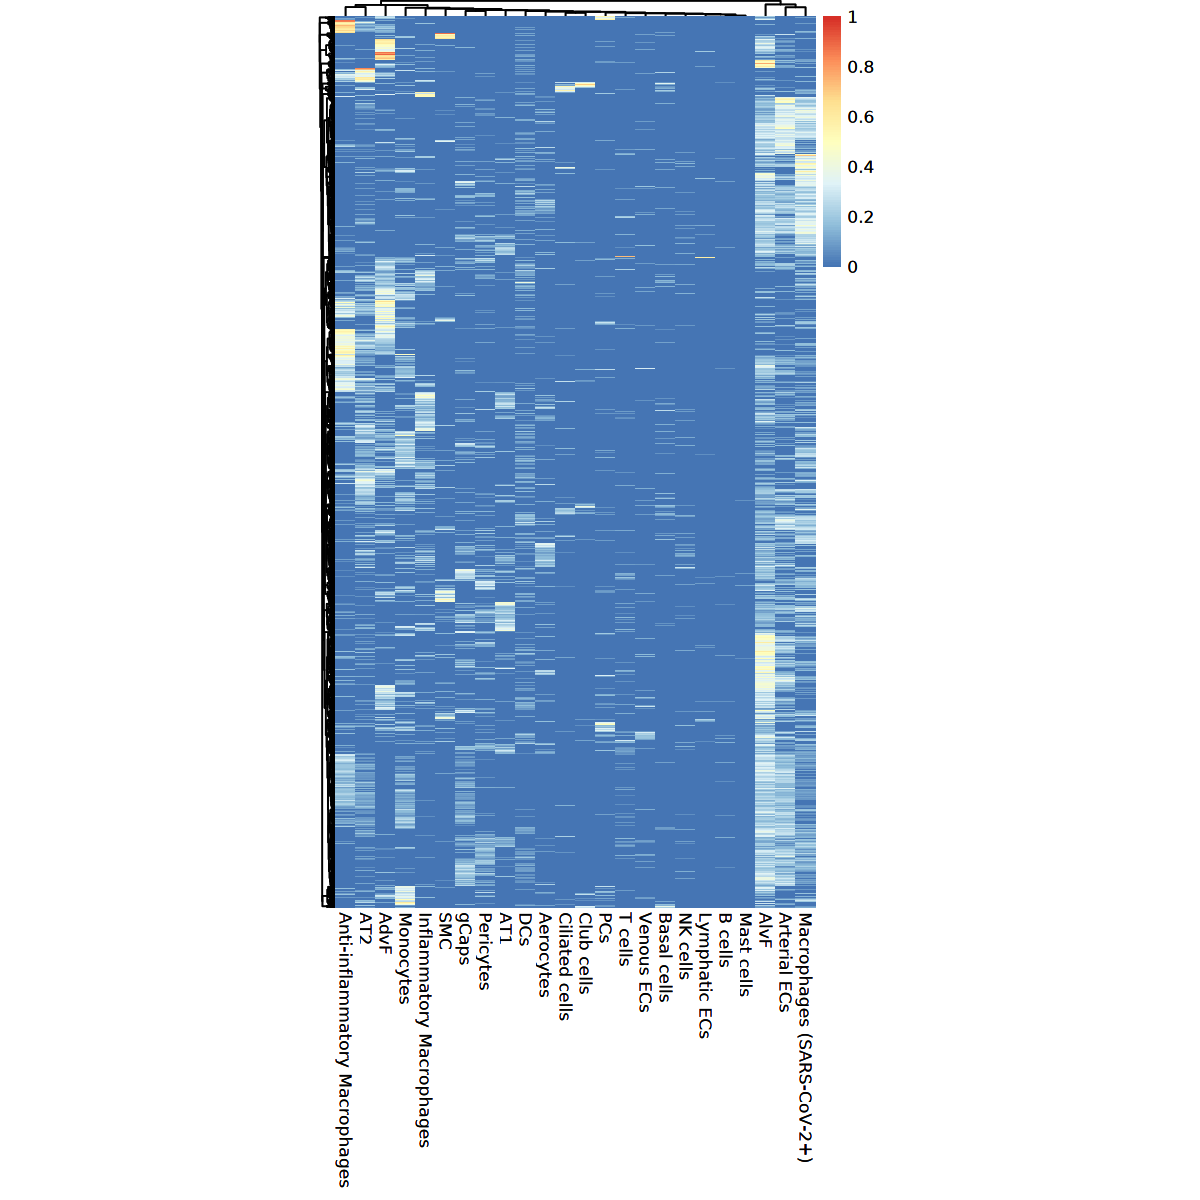

In [7]:
options(repr.plot.width = 10, repr.plot.height = 10, warn = -1)
plot_heat_ws <- \(ws){
    p <- pheatmap(ws, 
        show_rownames = FALSE, show_colnames = TRUE,
        cellwidth = 12, treeheight_row = 5, treeheight_col = 5)
    return(p)
}
plot_heat_ws(ws) 

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.
Coordinate system already present.
ℹ Adding new coordinate syste

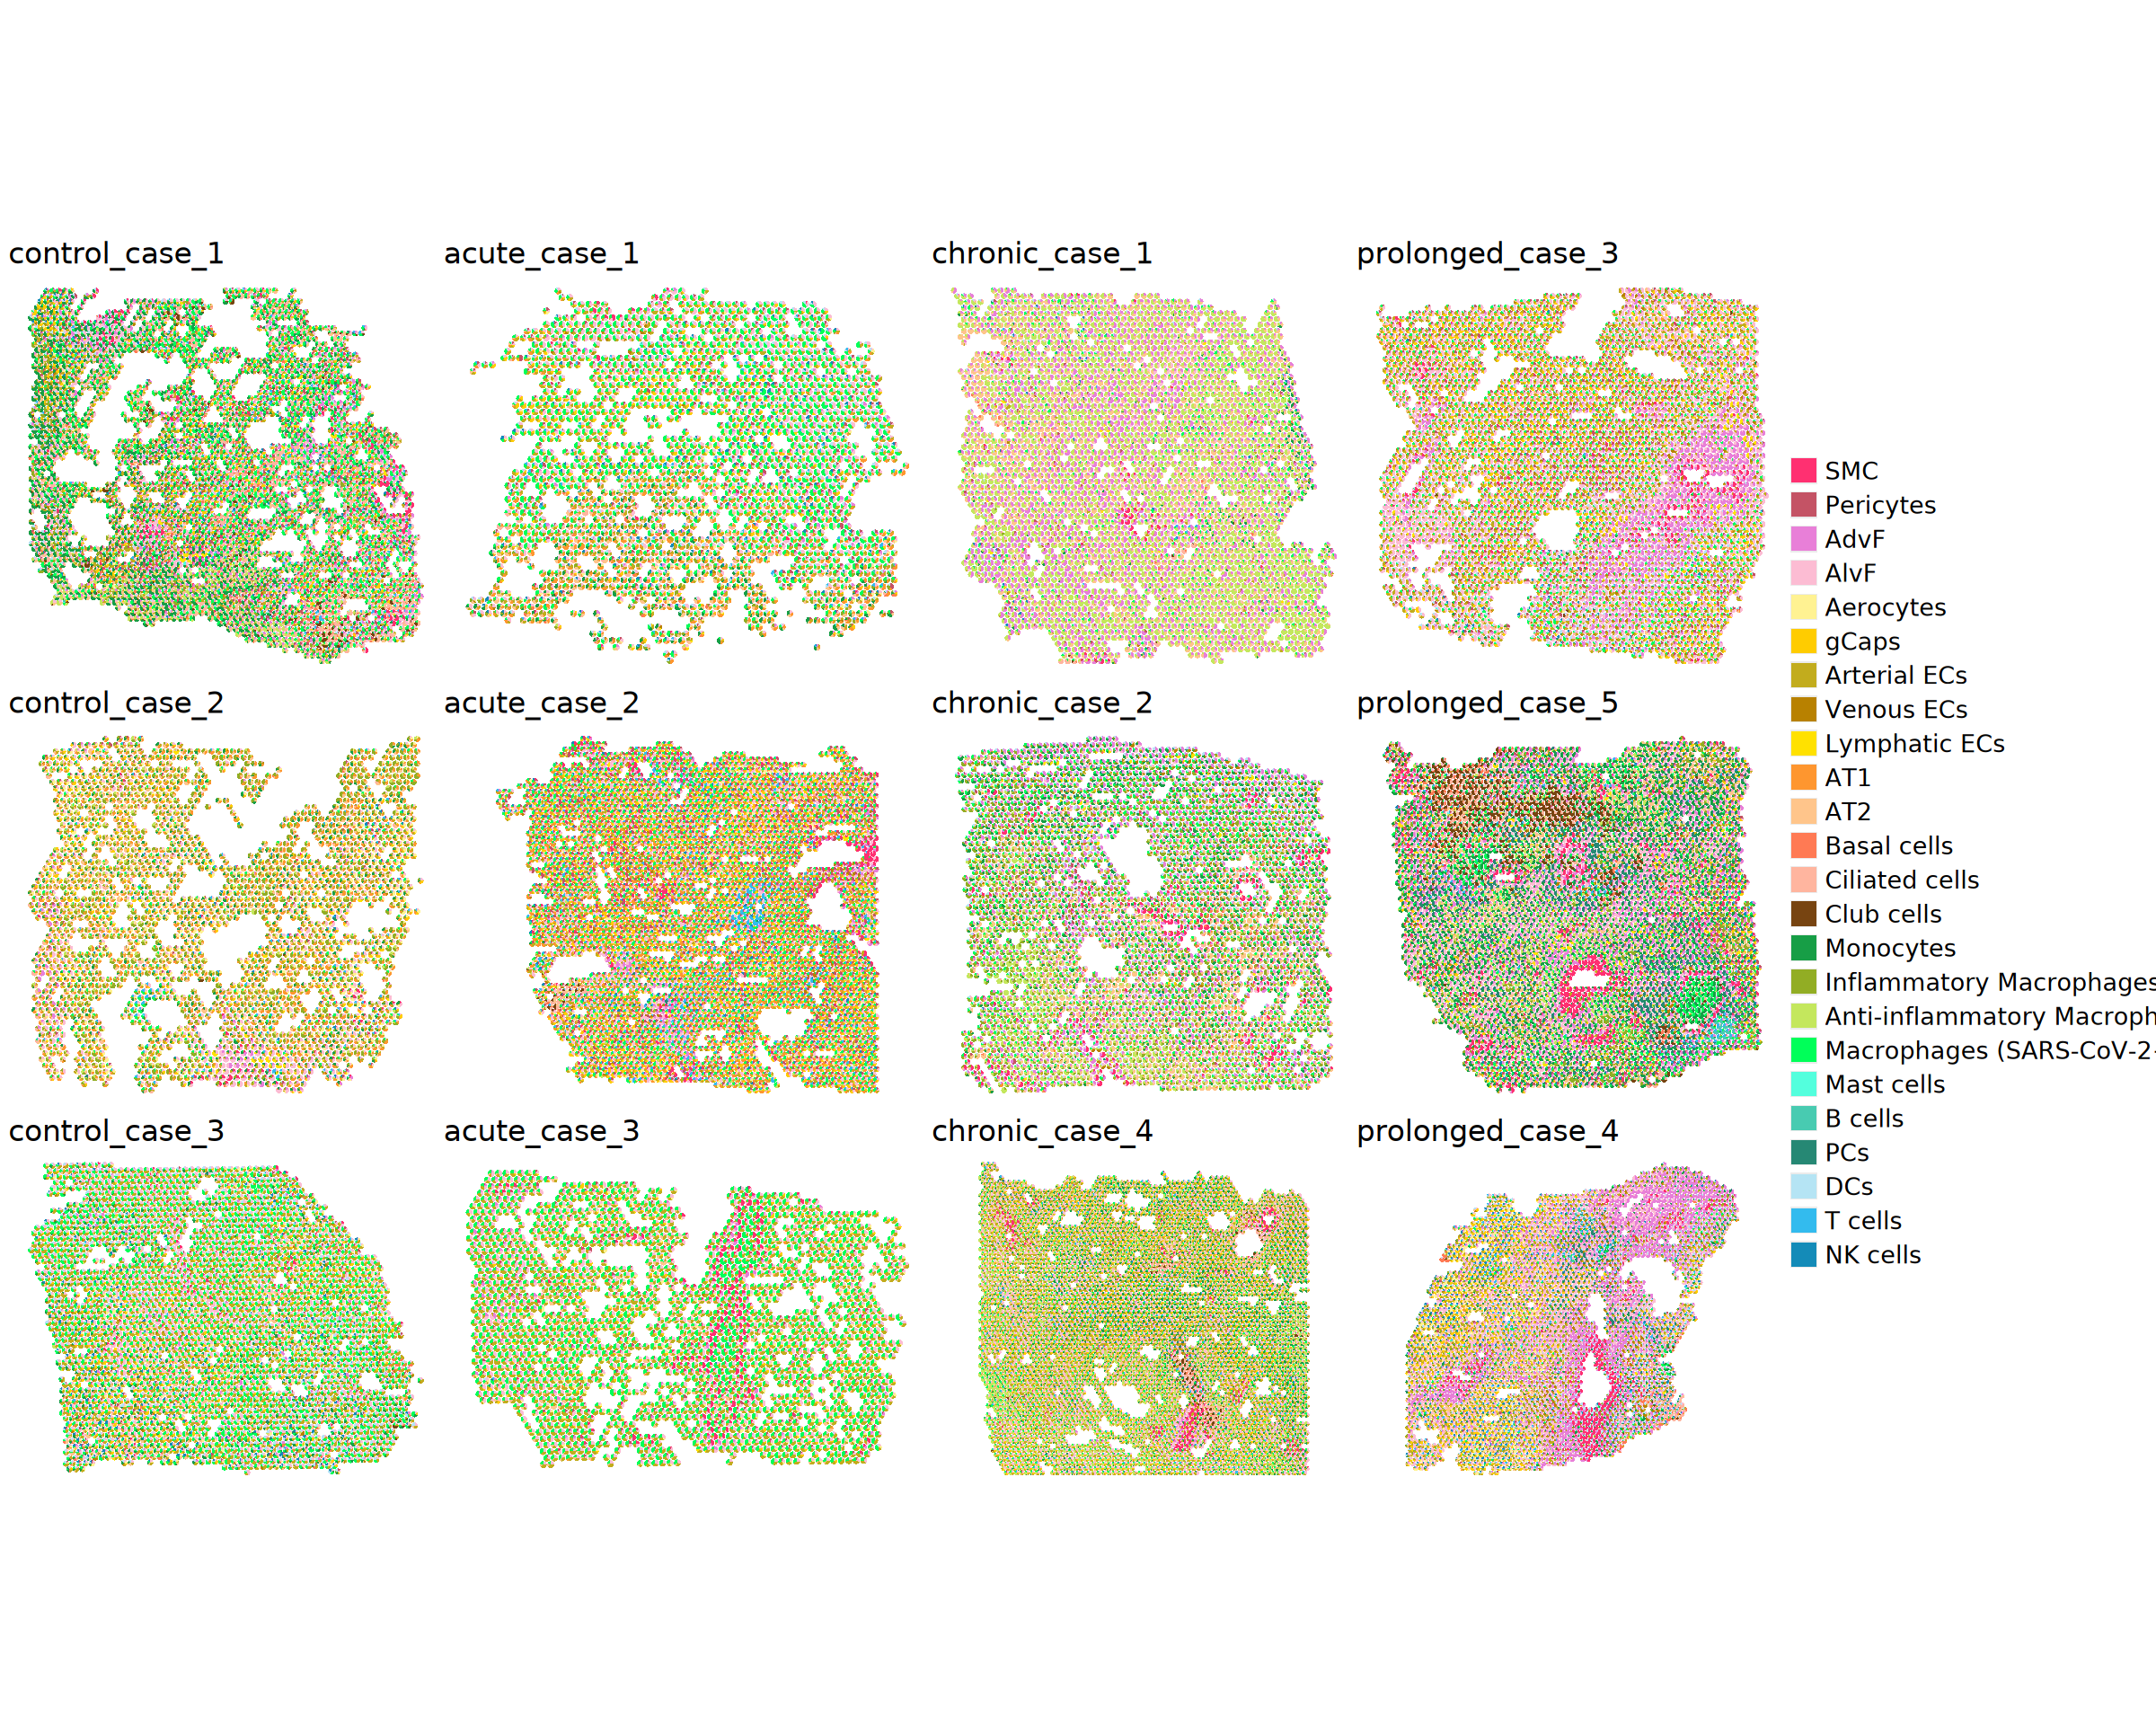

In [8]:
options(repr.plot.width = 20, repr.plot.height = 16, warn = -1)

plot_list <- lapply(unique(sub("-lung_.*", "", colnames(res))), function(id) {
    spots <- colnames(res)[sub("-lung_.*", "", colnames(res)) == id]
    sub_spe <- spe[, spots]
    sub_mat <- ws[spots,]
    
    plotSpatialScatterpie(x = sub_spe, y = sub_mat,
                          cell_types = ct, img = FALSE,
                          scatterpie_alpha = 1, pie_scale = 0.4) +
        ggtitle(id) +
        coord_fixed() +
        scale_fill_manual(values = palette, breaks = ct, limits = ct) +
        theme(text = element_text(size = 16),
              legend.position = "none")
})

legend_plot <- ggplot(
    data.frame(ct = factor(ct, levels = ct), x = 1, y = seq_along(ct)),
    aes(x, y, fill = ct)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = palette, breaks = ct, limits = ct, name = "") +
    theme(legend.position = "bottom",
          legend.background = element_blank(),
          legend.text = element_text(size = 16),
          legend.title = element_text(size = 16),
          legend.key = element_rect(color = NA)) +
    guides(fill = guide_legend(ncol = 1))

legend <- cowplot::get_legend(legend_plot)
p <- cowplot::plot_grid(wrap_plots(plot_list, byrow = FALSE), legend, rel_widths = c(1, 0.2))

ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/spatial_scatterpie_lung_deconv.svg", plot = p, device = svglite, width = 20, height = 16)
print(p)

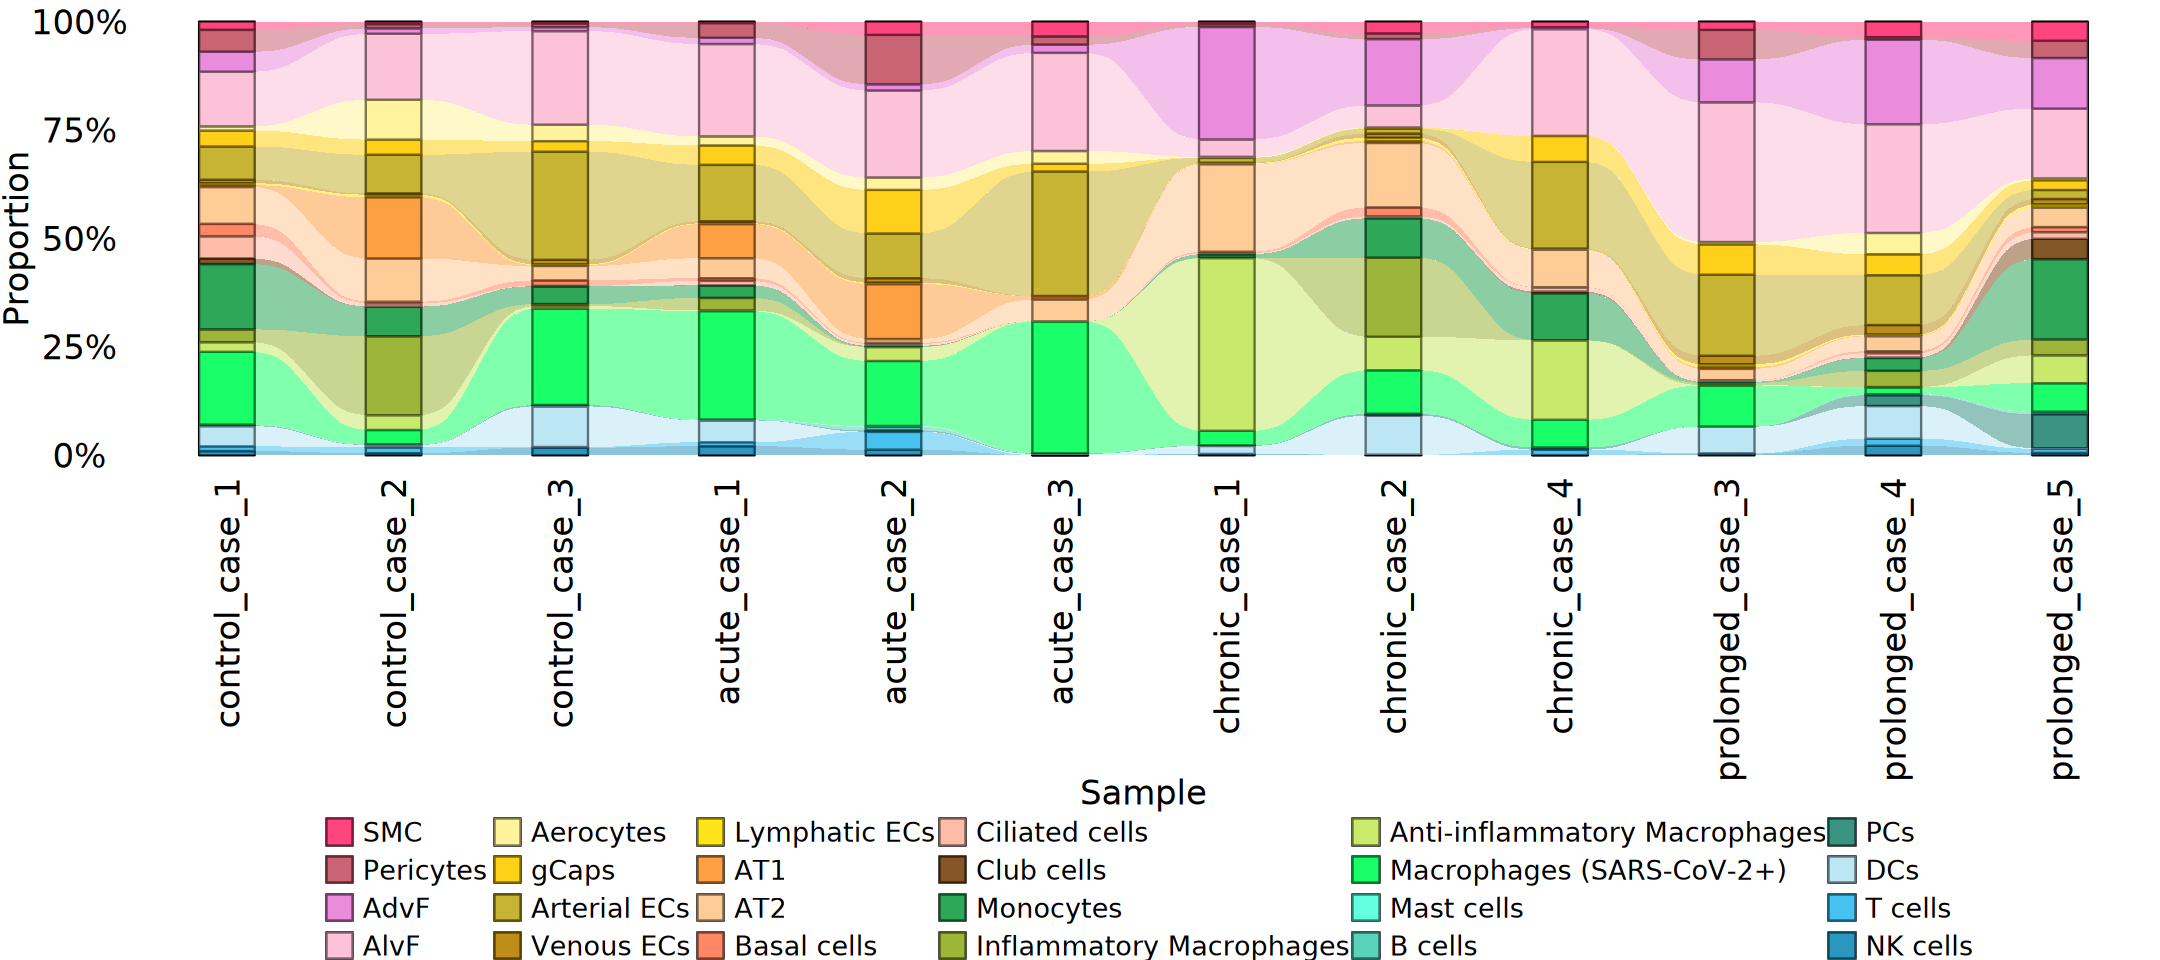

In [9]:
options(repr.plot.width = 18, repr.plot.height = 8, warn = -1)

mat <- assay(res)
df <- as.data.frame(ws)  
df$study_id <- sub("-lung_.*", "", rownames(df))

p <- df %>%
    pivot_longer(-study_id, names_to = "cell_type", values_to = "proportion") %>%
    group_by(study_id, cell_type) %>%
    summarise(proportion = sum(proportion), .groups = "drop") %>%
    group_by(study_id) %>%
    mutate(proportion = proportion / sum(proportion)) %>%
    mutate(study_id = factor(study_id,
                             levels = c("control_case_1", "control_case_2", "control_case_3",
                                        "acute_case_1", "acute_case_2", "acute_case_3",
                                        "chronic_case_1", "chronic_case_2", "chronic_case_4",
                                        "prolonged_case_3", "prolonged_case_4", "prolonged_case_5"))) %>%
    mutate(cell_type = factor(cell_type, levels = ct)) %>%
    ggplot(aes(x = study_id, y = proportion,
               stratum = cell_type, alluvium = cell_type, fill = cell_type)) +
        ggalluvial::geom_stratum(alpha = 0.8) +
        ggalluvial::geom_alluvium(alpha = 0.5) +
        scale_y_continuous(labels = scales::percent_format()) +
        scale_fill_manual(values = palette, breaks = ct, limits = ct, name = "") +
        labs(x = "Sample", y = "Proportion", fill = "") +
        theme_void() +
        theme(axis.text = element_text(color = "black", size = 20),
              axis.text.x = element_text(angle = 90, hjust = 1),
              axis.title = element_text(color = "black", size = 20),
              axis.title.y = element_text(angle = 90),
              legend.text = element_text(size = 16),
              legend.title = element_text(size = 16),
              legend.position = "bottom") +
        guides(fill = guide_legend(nrow = 4))

print(p)

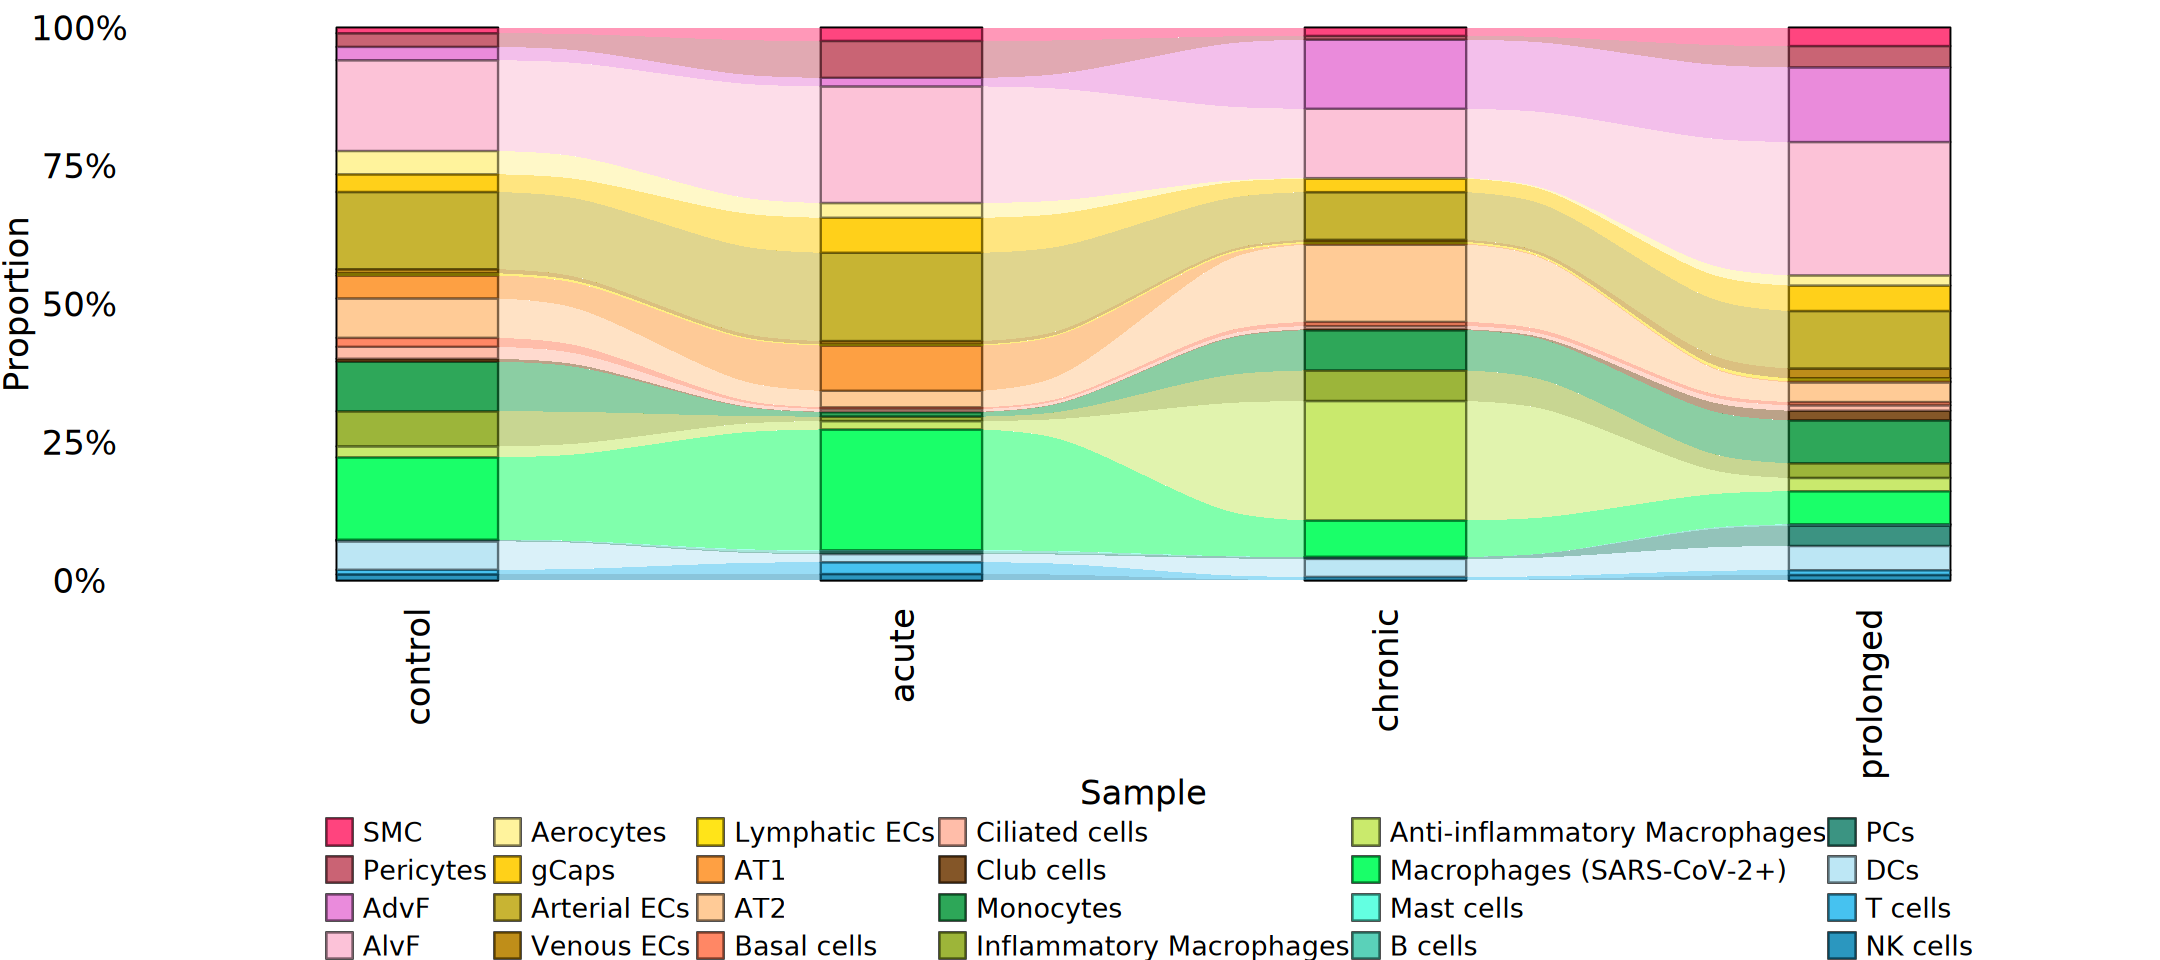

In [10]:
options(repr.plot.width = 18, repr.plot.height = 8, warn = -1)
df <- as.data.frame(ws)
df$disease_group <- sub("_case_.*", "", rownames(df))
p <- df %>%
    pivot_longer(-disease_group, names_to = "cell_type", values_to = "proportion") %>%
    group_by(disease_group, cell_type) %>%
    summarise(proportion = sum(proportion), .groups = "drop") %>%
    group_by(disease_group) %>%
    mutate(proportion = proportion / sum(proportion)) %>%
    mutate(disease_group = factor(disease_group,
                             levels = c("control", "acute", "chronic", "prolonged"))) %>%
    mutate(cell_type = factor(cell_type, levels = ct)) %>%
    ggplot(aes(x = disease_group, y = proportion, 
               stratum = cell_type, alluvium = cell_type, fill = cell_type)) +
        ggalluvial::geom_stratum(alpha = 0.8) +
        ggalluvial::geom_alluvium(alpha = 0.5) +
        scale_y_continuous(labels = scales::percent_format()) +
        scale_fill_manual(values = palette, breaks = ct, limits = ct, name = "") +
        labs(x = "Sample", y = "Proportion", fill = "") +
        theme_void() +
        theme(axis.text = element_text(color = "black", size = 20),
              axis.text.x = element_text(angle = 90, hjust = 1),
              axis.title = element_text(color = "black", size = 20),
              axis.title.y = element_text(angle = 90),
              legend.text = element_text(size = 16),
              legend.title = element_text(size = 16),
              legend.position = "bottom") +
        guides(fill = guide_legend(nrow = 4))
ggsave("~/SP-COVID/visium/1-deconvolution/out/plots/barplot_stage_lung_deconv.svg", plot = p, device = svglite, width = 20, height = 16)
print(p)

# Session information

In [35]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] svglite_2.2.2               NMF_0.28                   
 [3] cluster_2.1.8.2             rngtools_1.5.2             
 [5] registry_0.5-1              SPOTlight_1.14.0           
 [7] ggspavis_